In [1]:
import os
os.getcwd()


'C:\\Users\\ASUS\\Desktop\\NLP_Brand_Sentiment\\notebooks'

In [2]:
from dotenv import load_dotenv
import os
from newsapi import NewsApiClient

# Load the .env file
load_dotenv()

# Read your key from environment
key = os.getenv("NEWSAPI_KEY")
print("Your API key:", key[:8] + "..." if key else "❌ Key not found")

# Try a simple query
newsapi = NewsApiClient(api_key=key)
articles = newsapi.get_everything(q="Tesla", language="en", page_size=5)

print(f"✅ Retrieved {len(articles['articles'])} articles")
for a in articles['articles'][:3]:
    print("-", a['title'])

Your API key: 3fa2ea50...
✅ Retrieved 5 articles
- Elon Musk says he needs $1 trillion to control Tesla’s ‘robot army’
- Musk wants to get rid of Tesla’s robotaxi babysitters ‘by the end of the year’
- Spit On, Sworn At, and Undeterred: What It’s Like to Own a Cybertruck


In [3]:
import os
from dotenv import load_dotenv
import praw

load_dotenv()  # reload .env values

print("Client ID:", os.getenv("REDDIT_CLIENT_ID"))
print("Client Secret:", os.getenv("REDDIT_CLIENT_SECRET"))
print("User Agent:", os.getenv("REDDIT_USER_AGENT"))

# initialize Reddit
reddit = praw.Reddit(
    client_id=os.getenv("REDDIT_CLIENT_ID"),
    client_secret=os.getenv("REDDIT_CLIENT_SECRET"),
    user_agent=os.getenv("REDDIT_USER_AGENT")
)

# simple test
print("✅ Reddit instance created")

try:
    for submission in reddit.subreddit("all").search("Flipkart", limit=3):
        print("-", submission.title)
    print("\n✅ Reddit API is working")
except Exception as e:
    print("❌ Error:", e)

Client ID: qmxO3ACYcP5xfZNgrrOOnA
Client Secret: inoDUPPJKEia3ncYyAFeJ60OWbiBLg
User Agent: BrandSentimentApp/0.1 by Cultural-Chapter-837
✅ Reddit instance created
- I FINALLY WON VS FLIPKART
- Another day another Flipkart scam
- Shopping on Flipkart is insufferable nowadays. What are they even smoking?? [Not OC]

✅ Reddit API is working


In [4]:
import pandas as pd
from newsapi import NewsApiClient
import praw
from dotenv import load_dotenv
import os
from tqdm import tqdm

# Load environment variables
load_dotenv()

# Initialize clients
newsapi = NewsApiClient(api_key=os.getenv("NEWSAPI_KEY"))
reddit = praw.Reddit(
    client_id=os.getenv("REDDIT_CLIENT_ID"),
    client_secret=os.getenv("REDDIT_CLIENT_SECRET"),
    user_agent=os.getenv("REDDIT_USER_AGENT")
)

def collect_brand_data(brand_name, news_limit=20, reddit_limit=20):
    """Fetch data from NewsAPI + Reddit for a given brand"""
    data = []

    print(f"\n📰 Collecting news articles for: {brand_name}")
    news = newsapi.get_everything(q=brand_name, language='en', page_size=min(news_limit, 100))
    for article in tqdm(news['articles']):
        data.append({
            'source': 'news',
            'title': article['title'],
            'text': article.get('description', ''),
            'url': article['url']
        })

    print(f"\n👥 Collecting Reddit posts for: {brand_name}")
    for submission in tqdm(reddit.subreddit("all").search(brand_name, limit=reddit_limit, time_filter='month')):
        data.append({
            'source': 'reddit',
            'title': submission.title,
            'text': submission.selftext,
            'url': submission.url
        })

    df = pd.DataFrame(data)
    print(f"\n✅ Total {len(df)} records collected ({len(news['articles'])} news + {reddit_limit} reddit)")
    return df


In [6]:
brand_df = collect_brand_data("Flipkart", news_limit=10, reddit_limit=10)
brand_df.sample(10)


📰 Collecting news articles for: Flipkart


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 8233.81it/s]



👥 Collecting Reddit posts for: Flipkart


10it [00:00, 16.70it/s]


✅ Total 20 records collected (10 news + 10 reddit)


,source,title,text,url
7,news,Samsung launches two similar affordable phones...,"After launching the Galaxy A07, its cheapest p...",https://www.sammobile.com/news/samsung-launche...
6,news,Motorola QLED 4K Smart Google TV Review: Premi...,When I first spotted Motorola’s new QLED 4K Sm...,https://40fakes.com/motorola-qled-4k-smart-goo...
14,reddit,Playstation 5 - Pure Harassment by Flipkart,Like the most of you I was over the moon when ...,https://i.redd.it/zrsn323v1nuf1.jpeg
15,reddit,Any other fee left? Purchasing from Flipkart,,https://i.redd.it/5hcrq5x5b9xf1.jpeg
8,news,Over 40 billion records left publicly exposed ...,An Indian marketing company kept an open datab...,https://www.techradar.com/pro/security/over-40...
19,reddit,Tf is Flipkart even advertising 😂,"I don’t even use flipkart, and obviously don’t...",https://i.redd.it/w76l4m8uvmyf1.jpeg
16,reddit,This is how I received my vaseline lotion from...,I've received refund in gift card.,https://i.redd.it/p2g6h0ulwntf1.jpeg
1,news,"AI giants Anthropic, OpenAI, and Perplexity ar...","OpenAI, Anthropic, and Perplexity expand in In...",https://www.businessinsider.com/openai-anthrop...
2,news,Motorola Moto G06 Power's India launch date re...,After teasing the launch of the Moto G06 Power...,https://www.gsmarena.com/motorola_moto_g06_pow...
5,news,"India’s e-commerce to exceed $200bn next year,...",GlobalData expects India’s e-commerce market t...,https://www.retail-insight-network.com/feature...


In [10]:
!pip install nltk regex


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [15]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Clean and normalize text data."""
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 4. Tokenize
    tokens = word_tokenize(text)
    
    # 5. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # 6. Join back into a single string
    cleaned_text = " ".join(tokens)
    
    return cleaned_text

In [16]:
brand_df['clean_text'] = brand_df['text'].apply(clean_text)
brand_df[['source', 'text', 'clean_text']].head()

,source,text,clean_text
0,news,"Super.money, the fintech arm of Flipkart, is l...",supermoney fintech arm flipkart looking raise ...
1,news,"OpenAI, Anthropic, and Perplexity expand in In...",openai anthropic perplexity expand india setti...
2,news,After teasing the launch of the Moto G06 Power...,teasing launch moto g power india motorola ann...
3,news,Motorola recently started teasing the launch o...,motorola recently started teasing launch new s...
4,news,Over 60 distinct roles were offered by a large...,distinct roles offered large pool recruiters l...


In [17]:
brand_df['length'] = brand_df['clean_text'].apply(lambda x: len(x.split()))
brand_df['length'].describe()


count     20.000000
mean      37.150000
std       61.197932
min        0.000000
25%       12.500000
50%       15.000000
75%       22.750000
max      235.000000
Name: length, dtype: float64

In [18]:
!pip install vaderSentiment


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd


In [20]:
analyzer = SentimentIntensityAnalyzer()

# Quick test
sample_text = "Flipkart's customer service is amazing, but delivery is slow."
print(analyzer.polarity_scores(sample_text))


{'neg': 0.0, 'neu': 0.769, 'pos': 0.231, 'compound': 0.34}


In [22]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    if score['compound'] >= 0.05:
        return 'Positive'
    elif score['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

brand_df['sentiment'] = brand_df['clean_text'].apply(get_sentiment)
brand_df[['source', 'clean_text', 'sentiment']].head(20)

,source,clean_text,sentiment
0,news,supermoney fintech arm flipkart looking raise ...,Positive
1,news,openai anthropic perplexity expand india setti...,Positive
2,news,teasing launch moto g power india motorola ann...,Positive
3,news,motorola recently started teasing launch new s...,Negative
4,news,distinct roles offered large pool recruiters l...,Neutral
5,news,globaldata expects indias ecommerce market gro...,Positive
6,news,first spotted motorolas new qled k smart googl...,Positive
7,news,launching galaxy cheapest phone year samsung l...,Positive
8,news,indian marketing company kept open database fi...,Neutral
9,news,samsung quietly launched galaxy g india lets h...,Positive


<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

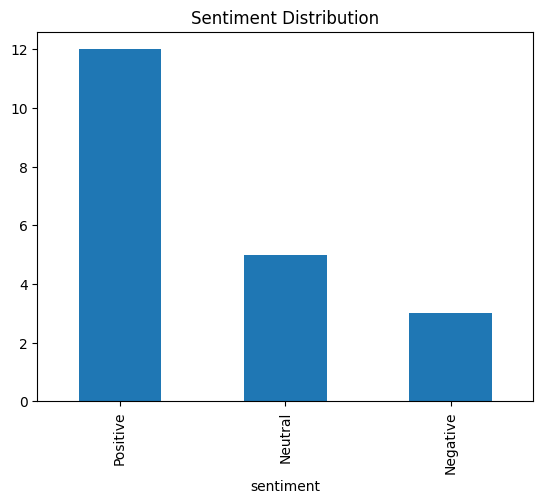

In [23]:
brand_df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')


In [24]:
!pip install matplotlib seaborn wordcloud



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17888\3848872925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=brand_df, palette='coolwarm')


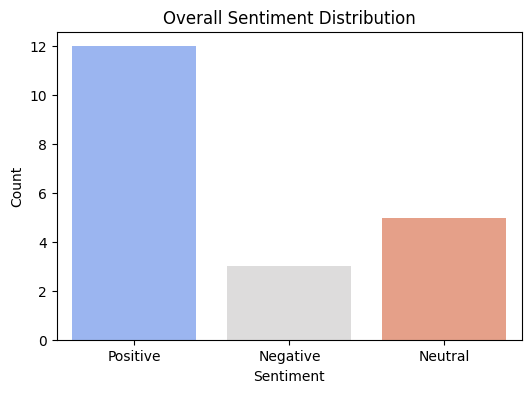

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=brand_df, palette='coolwarm')
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


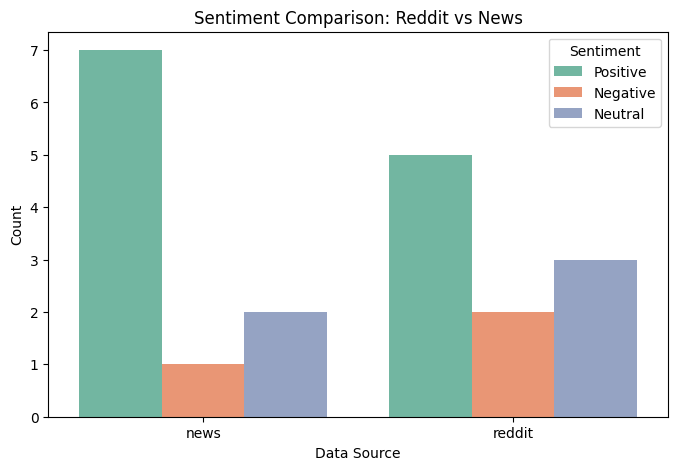

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='source', hue='sentiment', data=brand_df, palette='Set2')
plt.title('Sentiment Comparison: Reddit vs News')
plt.xlabel('Data Source')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()


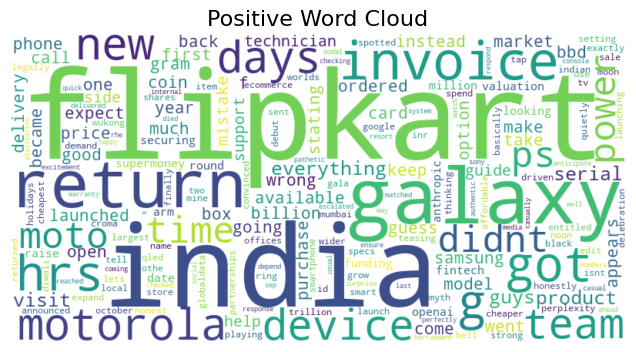

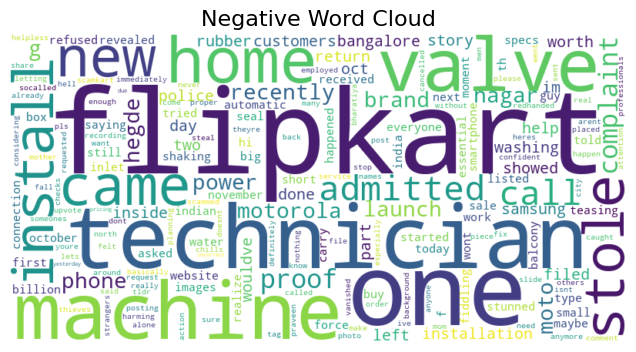

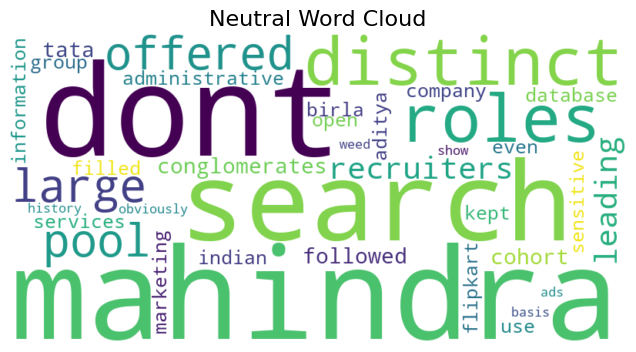

In [27]:
from wordcloud import WordCloud

def plot_wordcloud(df, sentiment):
    text = " ".join(df[df['sentiment']==sentiment]['clean_text'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{sentiment} Word Cloud", fontsize=16)
    plt.show()

plot_wordcloud(brand_df, 'Positive')
plot_wordcloud(brand_df, 'Negative')
plot_wordcloud(brand_df, 'Neutral')


In [28]:
brand_df['sentiment'].value_counts(normalize=True).round(2) * 100


sentiment
Positive    60.0
Neutral     25.0
Negative    15.0
Name: proportion, dtype: float64